## Ejercicio de Programación 3 - RFI sobre visibilidades reales

1. Implementar diferentes tipos de RFI según las fórmulas
2. Aplicar RFI a las visibilidades simuladas
3. Analizar el impacto en amplitud y fase
4. Visualizar la distribución de RFI en el plano UV
5. Calcular estadísticas de contaminación



In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# imports
from numba import cuda
import math
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
# modules
from modules.simulation import visibilities_simulation
from modules.plots import plot_uv_coverage, plot_uv_coverage_2


/home/vcnt/y/envs/radiointerferometry-env/lib/python3.13/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


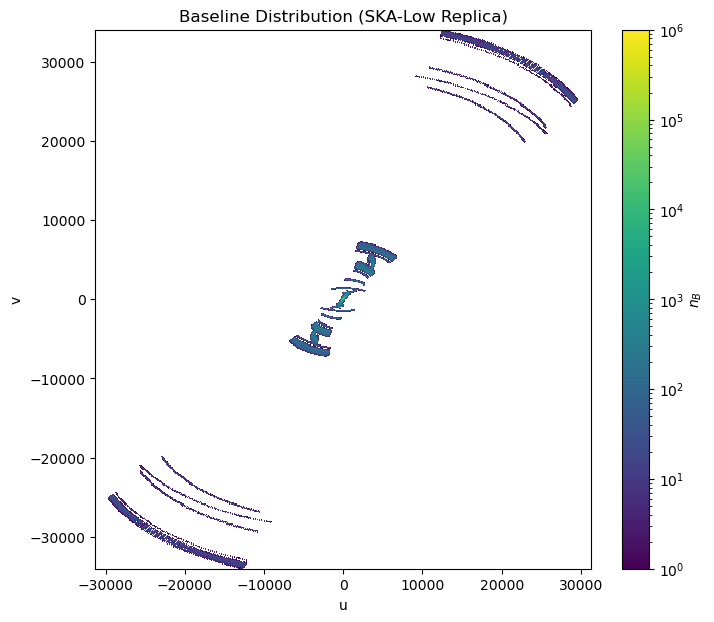

In [ ]:
# simulate visibilities no grid
SKA_LOW_AA1 = {
    "latitude": -26.696, 
    "longitude": 116.637,
    "file_route": "../antenna_arrays/ska_low_AA2.cfg",
    "ra-dec": [0, -30],
    "utc_start": "2023-11-21T06:00:00",
    "utc_end": "2023-11-21T06:10:00",
    "step_min": 0.5,
    "n_freqs": 1500,
    'bandwidth': None, # Mhz   
    "interferometer": {
        "name": "SKA_LOW", 
        "band_name": "BAND" 
    },
    "n_sources": 1,
    "max_offset_deg": 1.0, 
    "flux_range": [0.1, 2.0],
    "seed": 42
}

V, uvw, uvw_lambda, [frequencies, channel_bandwidth], baselines_enu, _ , _ , times_sec = visibilities_simulation(SKA_LOW_AA1)

# plot_uv_coverage(uvw, unit='km')
plot_uv_coverage_2(uvw, 512)

In [9]:
print("uvw shape: ", uvw.shape)
print("V shape: ", V.shape)
print("V baselines shape: ", V[0].shape)
# print("Primeros 3 registros del baseline 0: \n", V[0][:3])   

uvw shape:  (2016, 91, 3)
V shape:  (2016, 91, 1000)
V baselines shape:  (91, 1000)


Inyección de RFI

In [38]:
from modules.noise import narrowband_rfi, broadband_rfi, transient_rfi

V_rfi, k, f_rfi = narrowband_rfi(
    V,
    frequencies,
    amplitude=(0,5),
    k_rfi=[10, 90, 175, 210, 97, 14, 15, 26, 431, 708, 900],
    duty_cycle=0.6,
)


V_rfi_bb, k_bb, f_rfi_bb = broadband_rfi(
    V,
    frequencies,
    amplitude=(0,5),
    k_range=(300,378),
    duty_cycle=0.1
)

V_rfi_t, k_t = transient_rfi(
    V,
    times=times_sec,
    amplitude=10,
    n_step=[10, 50, 75],
    duration_steps=1,
    # t_rfi=3600
)

print("Canal RFI:", k)
print("Frecuencia [MHz]:", f_rfi / 1e6)


V_corrupted = V + V_rfi + V_rfi_bb + V_rfi_t

Canal RFI: [ 10  90 175 210  97  14  15  26 431 708 900]
Frecuencia [MHz]: [ 53.003003    77.02702703 102.55255255 113.06306306  79.12912913
  54.2042042   54.5045045   57.80780781 179.42942943 262.61261261
 320.27027027]


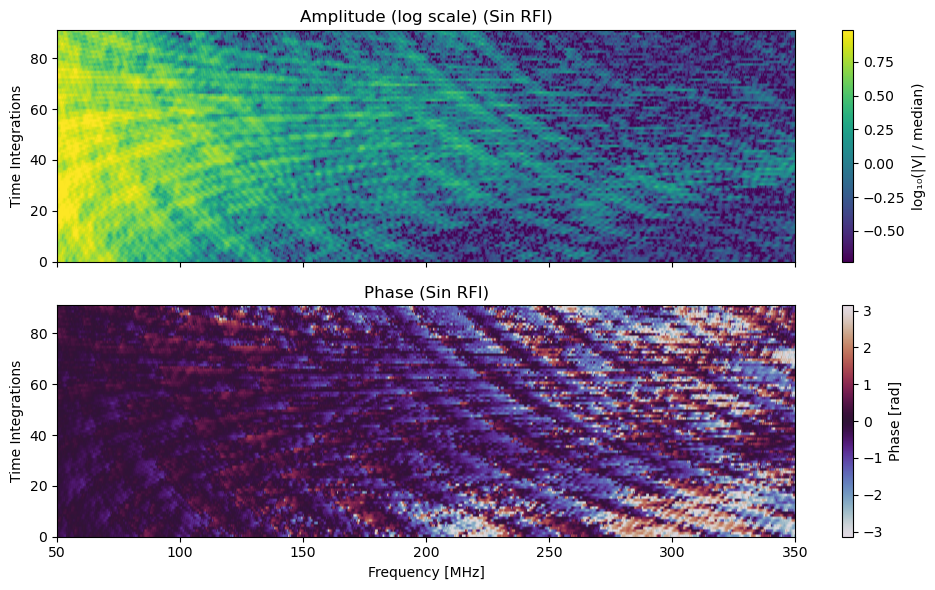

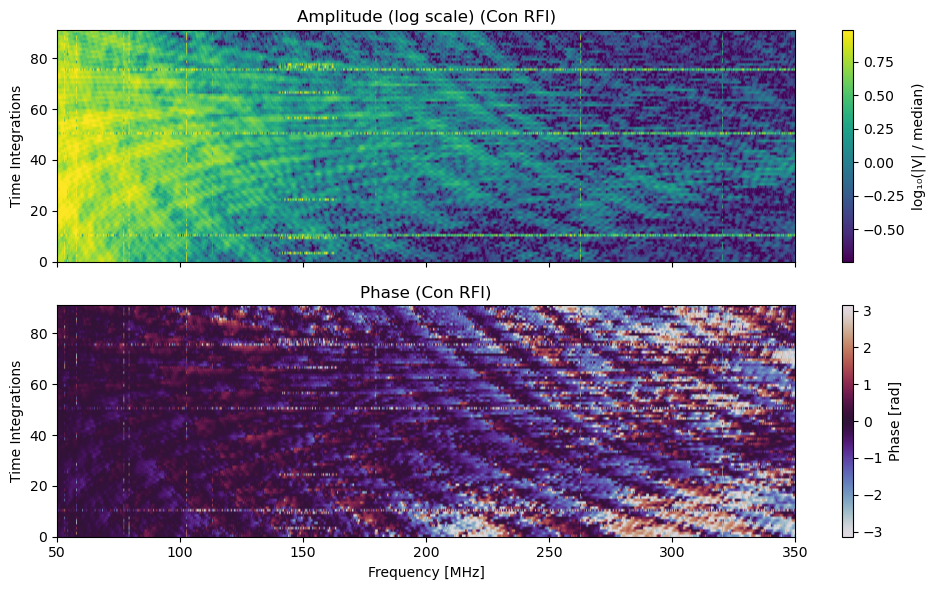

In [23]:
from modules.plots import plot_time_frequency

plot_time_frequency(
    V,
    frequencies,
    title_suffix="(Sin RFI)"
)

plot_time_frequency(
    V_corrupted,
    frequencies,
    title_suffix="(Con RFI)"
)

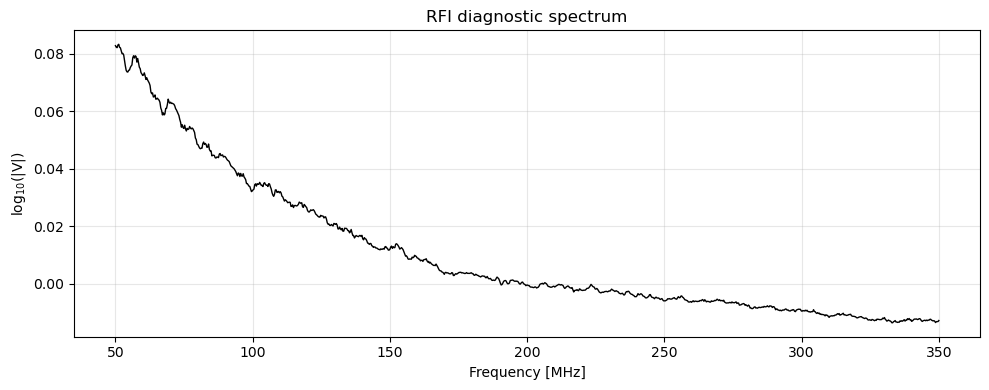

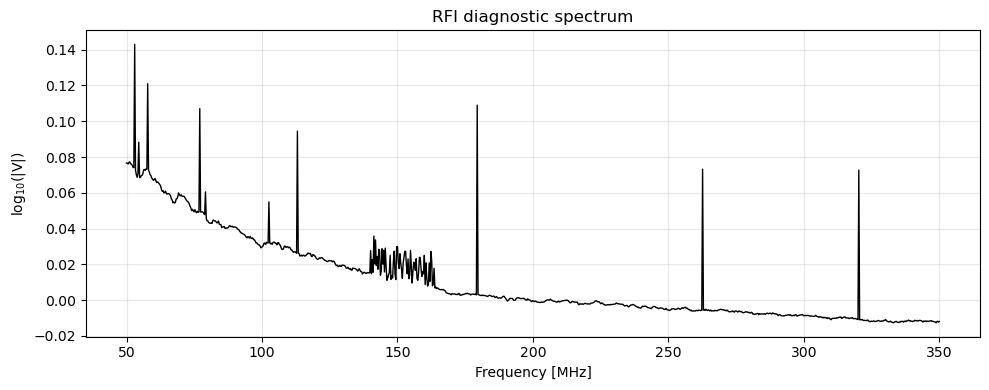

In [39]:
from modules.plots import plot_rfi_spectrum

plot_rfi_spectrum(
    V,
    frequencies,
    title="RFI diagnostic spectrum"
)

plot_rfi_spectrum(
    V_corrupted,
    frequencies,
    title="RFI diagnostic spectrum"
)


In [141]:
V_corrupted.shape

(2016, 91, 1000)